In [1]:
from mylib.statistic_test import *

code_id = '0812 - aPVC'
loc = os.path.join(figpath, 'Dsp', code_id)
mkdir(loc)
pass

d:\Softwares\Anaconda2025\envs\maze\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


        D:\Data\FinalResults\Dsp\0812 - aPVC is already existed!


# Fig. 2F

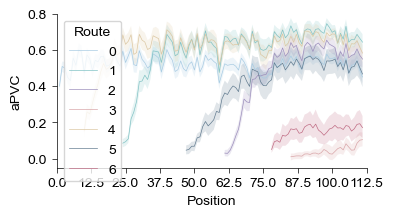

In [2]:
if os.path.exists(os.path.join(figdata, f"{code_id}.pkl")) == False:
    APVC = {
        "MiceID": [],
        "Session": [],
        "Route": [],
        "Position": [],
        "Node": [],
        "aPVC": []
    }
    
    rts = np.array([1,2,3,0,4,5,6,0])
    for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
        file_indices = np.where(f2['MiceID'] == mouse)[0]
        print(f"Mouse {mouse}")
        for j in tqdm(range(len(file_indices))):
            with open(f2['Trace File'][file_indices[j]], 'rb') as handle:
                trace = pickle.load(handle)
            
            for i, n in enumerate([1,2,3,4,6,7,8,9]):
                targ_nodes = 0 if i <= 3 else 5
                
                idx = np.where(
                    (trace[f'node {targ_nodes}']['is_placecell'] == 1) |
                    (trace[f'node {n}']['is_placecell'] == 1)
                )[0]
                
                pvcorr = np.zeros(CP_DSPs[1][0].shape[0]) * np.nan
                for k, b in enumerate(CP_DSPs[1][0]):
                    if b not in CP_DSPs[1][rts[i]]:
                        continue
                    
                    sonbins = Father2SonGraph[b]
                    pvcorr[k] = np.nanmean([np.corrcoef(
                        trace[f'node {targ_nodes}']['smooth_map_all'][idx, bb-1],
                        trace[f'node {n}']['smooth_map_all'][idx, bb-1]
                    )[0, 1] for bb in sonbins])
                
                nnidx = np.isnan(pvcorr) == False
                    
                rt = trace[f'node {n}']['Route']
                
                APVC["MiceID"].append(np.repeat(mouse, len(pvcorr)))
                APVC["Session"].append(np.repeat(j, len(pvcorr)))
                APVC["Route"].append(np.repeat(rt, len(pvcorr)))
                APVC["Position"].append(np.arange(1, len(pvcorr)+1))
                APVC["Node"].append(np.repeat(n, len(pvcorr)))
                APVC["aPVC"].append(pvcorr)
                
    for k in APVC.keys():
        APVC[k] = np.concatenate(APVC[k])
        
    with open(os.path.join(figdata, f"{code_id}.pkl"), 'wb') as handle:
        pickle.dump(APVC, handle)
        
    APVCD = pd.DataFrame(APVC)
    APVCD.to_excel(os.path.join(figdata, f"{code_id}.xlsx"), index=False)
    print(len(APVCD))
else:
    with open(os.path.join(figdata, f"{code_id}.pkl"), 'rb') as handle:
        APVC = pickle.load(handle)

# Retrieved Routes
fig = plt.figure(figsize=(4, 2))
ax = Clear_Axes(plt.axes(), close_spines=["top", "right"], ifxticks=True, ifyticks=True)
subdata = APVC
sns.lineplot(
    x='Position', 
    y='aPVC', 
    hue='Route', 
    data=subdata, 
    ax=ax, 
    palette=DSPPalette[:7],
    err_kws={'edgecolor': None},
    linewidth=0.5
)
ax.set_xlim(0, 112.5)
ax.set_xticks(np.linspace(0, 112.5, 10))
ax.set_ylim(-0.05, 0.8)
plt.savefig(os.path.join(loc, f"APVC.png"), dpi=600)
plt.savefig(os.path.join(loc, f"APVC.svg"), dpi=600)
plt.show()

# R7 vs. R1

# Extended Fig. 4

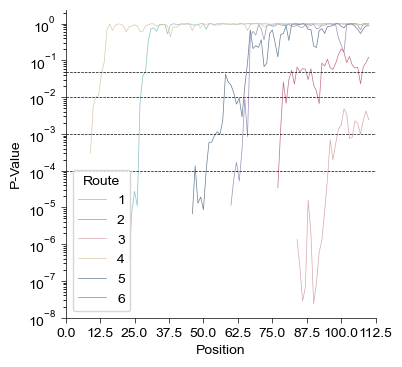

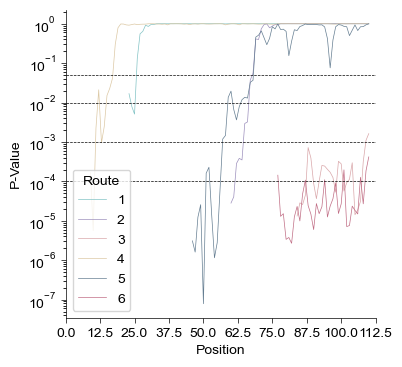

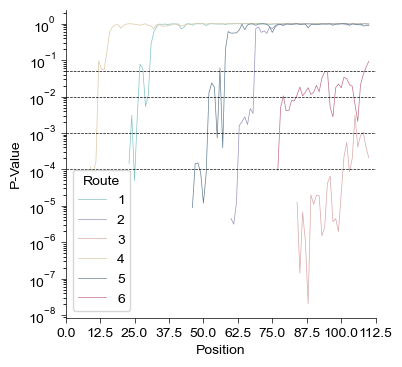

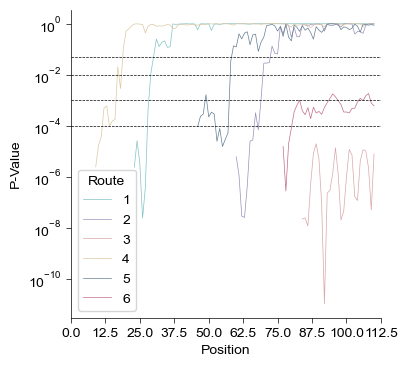

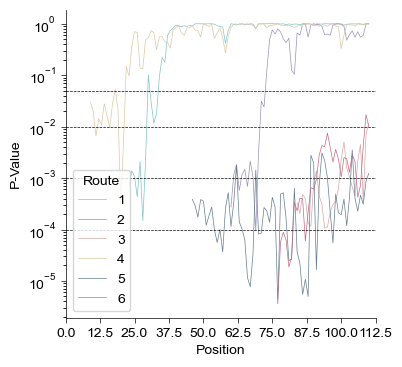

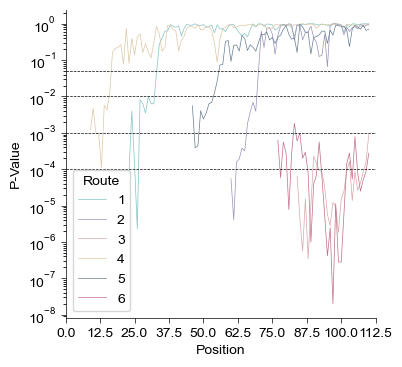

In [3]:
if exists(join(figdata, F"{code_id} - stats.xlsx")) == False:
    apvc_stats = {
        "MiceID": [],
        "Route": [],
        "P-Value": [],
        "Position": []
    }
    
    for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
        for rt in range(1, 7):
            if rt <= 3:
                targ_nodes = 4
            else:
                targ_nodes = 9
            
            for i, b in enumerate(CP_DSPs[1][0]):
                idx = np.where(
                    (APVC['MiceID'] == mouse) &
                    (APVC['Route'] == rt) &
                    (APVC['Position'] == i+1)
                )
                idx_targ = np.where(
                    (APVC['MiceID'] == mouse) &
                    (APVC['Route'] == 0) &
                    (APVC['Node'] == targ_nodes) &
                    (APVC['Position'] == i+1)
                )
                
                assert len(idx[0]) == len(idx_targ[0]), f"{mouse} {rt} {i+1}"
                
                pvalue = ttest_rel(APVC['aPVC'][idx], APVC['aPVC'][idx_targ], alternative='less')[1]
                apvc_stats["MiceID"].append(mouse)
                apvc_stats["Route"].append(rt)
                apvc_stats["P-Value"].append(pvalue)
                apvc_stats["Position"].append(i+1)
                
    for k in apvc_stats.keys():
        apvc_stats[k] = np.array(apvc_stats[k])
        
    with open(os.path.join(figdata, F"{code_id} - stats.pkl"), 'wb') as handle:
        pickle.dump(apvc_stats, handle)
        
    apvc_stats_df = pd.DataFrame(apvc_stats)
    apvc_stats_df.to_excel(os.path.join(figdata, F"{code_id} - stats.xlsx"), index=False)
    print(len(apvc_stats_df))
else:
    with open(os.path.join(figdata, F"{code_id} - stats.pkl"), 'rb') as handle:
        apvc_stats = pickle.load(handle)
        

for mouse in [10212, 10224, 10227, 10232, 10275, 10276]:
    subdata_mouse = SubDict(
        apvc_stats, apvc_stats.keys(), np.where(apvc_stats['MiceID'] == mouse)[0]
    )
    fig = plt.figure(figsize=(4, 4))
    ax = Clear_Axes(plt.axes(), close_spines=["top", "right"], ifxticks=True, ifyticks=True)
    subdata_mouse['Position'] -= 1
    sns.lineplot(
        x='Position', 
        y='P-Value', 
        hue='Route', 
        data=subdata_mouse,
        hue_order=[1, 2, 3, 4, 5, 6],
        ax=ax, 
        palette=DSPPalette[1:7],
        err_kws={'edgecolor': None},
        linewidth=0.5
    )
    ax.axhline(0.05, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(0.01, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(0.001, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(0.0001, color='k', linestyle='--', linewidth=0.5)
    ax.semilogy()
    ax.set_xlim(0, 112.5)
    ax.set_xticks(np.linspace(0, 112.5, 10))
    plt.savefig(os.path.join(loc, f"IS Retrieval P-values [{mouse}].png"), dpi=600)
    plt.savefig(os.path.join(loc, f"IS Retrieval P-values [{mouse}].svg"), dpi=600)
    plt.show()

# Fig. 2G Summary of Remapping

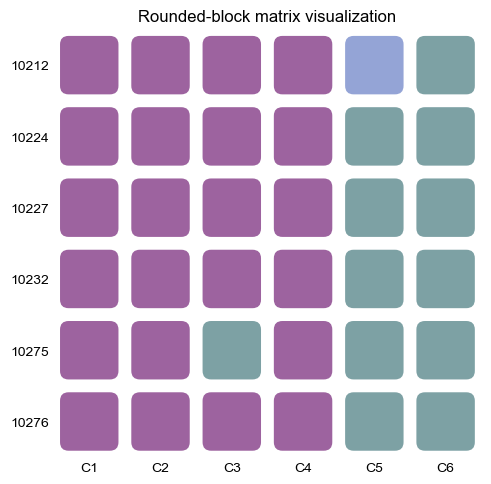

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import ListedColormap

res = np.array([
    [-1.5, -1.5, -1.5, -1.5, 0.5, 1.5],  # 10212
    [-1.5, -1.5, -1.5, -1.5, 1.5, 1.5],  # 10224
    [-1.5, -1.5, -1.5, -1.5, 1.5, 1.5],  # 10227
    [-1.5, -1.5, -1.5, -1.5, 1.5, 1.5],  # 10232
    [-1.5, -1.5, 1.5, -1.5, 1.5, 1.5],  # 10275
    [-1.5, -1.5, -1.5, -1.5, 1.5, 1.5]  # 10276
])

row_labels = ["10212", "10224", "10227", "10232", "10275", "10276"]
col_labels = [f"C{i+1}" for i in range(res.shape[1])]

# Manually assign colors to values
value_to_color = {
    -1.5: "#9d639f",
     0.5: "#94a4d6",
     1.5: "#7da1a4",
}

n_rows, n_cols = res.shape

fig, ax = plt.subplots(figsize=(5, 5))

block_size = 0.82      # smaller than 1.0 leaves blank space between blocks
rounding = 0.12        # larger value gives rounder corners

for i in range(n_rows):
    for j in range(n_cols):
        value = res[i, j]
        color = value_to_color[value]

        # Center each rounded block inside its grid cell
        x = j + (1 - block_size) / 2
        y = i + (1 - block_size) / 2

        patch = FancyBboxPatch(
            (x, y),
            block_size,
            block_size,
            boxstyle=f"round,pad=0,rounding_size={rounding}",
            facecolor=color,
            edgecolor="none"
        )

        ax.add_patch(patch)

ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)
ax.set_aspect("equal")

# Put row 1 at the top, like imshow
ax.invert_yaxis()

# Tick labels at the center of each block
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_yticks(np.arange(n_rows) + 0.5)

ax.set_xticklabels(col_labels)
ax.set_yticklabels(row_labels)

# Remove frame and tick marks
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(length=0)

ax.set_title("Rounded-block matrix visualization")

plt.tight_layout()
plt.savefig(os.path.join(loc, f"APVC Summary.png"), dpi=600)
plt.savefig(os.path.join(loc, f"APVC Summary.svg"), dpi=600)
plt.show()

# Illustrator of PVC, Fig. 2D

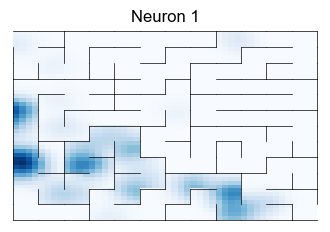

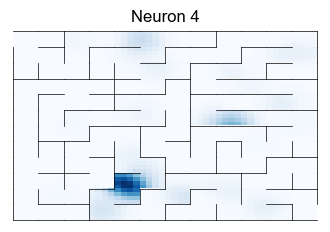

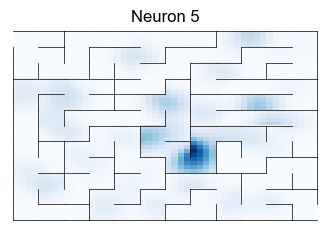

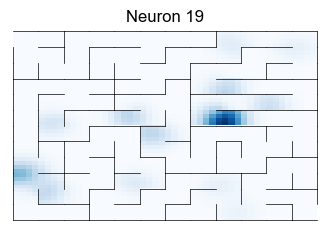

In [5]:
with open(f2['Trace File'][34], 'rb') as handle:
    trace = pickle.load(handle)
    # 10232, S7

pp = join(loc, "PVC Illustration")
os.makedirs(pp, exist_ok=True)
x = np.arange(48)
y = np.arange(48)
X, Y = np.meshgrid(x, y)
for i in [1, 4, 5, 19]:
    fig = plt.figure(figsize=(4, 2.5))
    ax = Clear_Axes(fig.add_subplot(111))
    
    ax.set_title(f"Neuron {i}")
    ratemap = trace['node 0']['smooth_map_all'][i, :].reshape(48, 48)
    vmax = np.nanmax(ratemap)
    #ax.plot_surface(X, Y, np.zeros_like(X), facecolors=plt.cm.Blues(ratemap), vmax=vmax, vmin=0,zorder=1)
    DrawMazeProfile(maze_type=1, ax=ax, color='k', linewidth=0.5,zorder=2)
    ax.imshow(ratemap, cmap='Blues', vmin=0, vmax=vmax, zorder=1)
    ax.set_ylim(48, -1)
    ax.set_aspect("auto")
    plt.savefig(os.path.join(pp, f"Neuron {i+1} [10232 S7].png"), dpi=600)
    plt.savefig(os.path.join(pp, f"Neuron {i+1} [10232 S7].svg"), dpi=600)
    plt.show()
    

# Fig. 2e
10224, S7

In [12]:
with open(f2['Trace File'][19], 'rb') as handle:
    trace = pickle.load(handle)

if os.path.exists(os.path.join(figdata, f" {code_id} [Example].pkl")) == False:
    PVC = np.zeros((9, 2304))

    for i in range(1, 4):
        for j in range(2304):
            PVC[i-1, j], _ = pearsonr(
                trace['node 0']['smooth_map_all'][:, j], 
                trace['node '+str(i)]['smooth_map_all'][:, j]
            )
        
        nanbins = np.setdiff1d(np.arange(1, 2305), get_son_area(CP_DSP1[trace[f'node {i}']['Route']])) - 1
        PVC[i-1, nanbins] = np.nan

    for i in range(6, 9):
        for j in range(2304):
            PVC[i-1, j], _ = pearsonr(
                trace['node 5']['smooth_map_all'][:, j], 
                trace['node '+str(i)]['smooth_map_all'][:, j]
            )
        
        nanbins = np.setdiff1d(np.arange(1, 2305), get_son_area(CP_DSP1[trace[f'node {i}']['Route']])) - 1
        PVC[i-1, nanbins] = np.nan
            
    with open(os.path.join(figdata, f"{code_id} [Example].pkl"), 'wb') as handle:
        pickle.dump(PVC, handle)
else:
    with open(os.path.join(figdata, f"{code_id} [Example].pkl"), 'rb') as handle:
        PVC = pickle.load(handle)

v_max, v_min = np.nanmax(PVC), np.nanmin(PVC)
print(v_max, v_min)
v_max = round(v_max, 2) + 0.001
v_min = round(v_min, 2) - 0.001
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i in range(3):
    for j in range(3):
        im = axes[i, j].imshow(PVC[i*3+j].reshape(48, 48), cmap='jet', vmin=v_min, vmax = v_max)
        axes[i, j].set_aspect('equal')
        axes[i, j] = Clear_Axes(axes[i, j])
        axes[i, j] = DrawMazeProfile(maze_type=1, axes=axes[i, j], nx=48, linewidth=0.5, color = 'black')
        axes[i, j].axis([-0.8, 47.8, 47.8, -0.8])

cbar = plt.colorbar(im)
cbar.set_ticks([v_min, 0, 0.2, 0.4, 0.6, 0.8, v_max])
plt.savefig(os.path.join(loc, 'Example PVC 10224.svg'), dpi=600)
plt.savefig(os.path.join(loc, 'Example PVC 10224.png'), dpi=600)
plt.close()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19016\2251557339.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  PVC[i-1, j], _ = pearsonr(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19016\2251557339.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  PVC[i-1, j], _ = pearsonr(


0.8570646221864071 -0.07815846464539442


# Fig. 2h

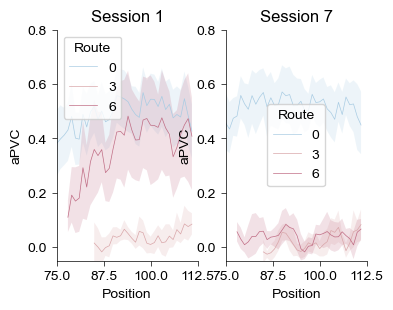

In [7]:
subdata_s1 = SubDict(APVC, APVC.keys(), np.where(np.isin(APVC['Route'], [0, 3, 6]) & (APVC['Session'] == 0) & (APVC['Position'] >= 75))[0])
subdata_s7 = SubDict(APVC, APVC.keys(), np.where(np.isin(APVC['Route'], [0, 3, 6]) & (APVC['Session'] == 6) & (APVC['Position'] >= 75))[0])

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(4, 3))
ax1 = Clear_Axes(axes[0], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='Position', 
    y='aPVC', 
    hue='Route', 
    data=subdata_s1, 
    ax=ax1, 
    palette=[DSPPalette[i] for i in [0, 3, 6]],
    err_kws={'edgecolor': None},
    linewidth=0.5
)
ax1.set_title("Session 1")
ax1.set_xlim(75, 112.5)
ax1.set_xticks(np.linspace(75, 112.5, 4))
ax1.set_ylim(-0.05, 0.8)
ax1.set_yticks(np.linspace(0, 0.8, 5))

ax2 = Clear_Axes(axes[1], close_spines=['top', 'right'], ifxticks=True, ifyticks=True)
sns.lineplot(
    x='Position', 
    y='aPVC', 
    hue='Route', 
    data=subdata_s7, 
    ax=ax2, 
    palette=[DSPPalette[i] for i in [0, 3, 6]],
    err_kws={'edgecolor': None},
    linewidth=0.5
)
ax2.set_title("Session 7")
ax2.set_xlim(75, 112.5)
ax2.set_xticks(np.linspace(75, 112.5, 4))
ax2.set_ylim(-0.05, 0.8)
ax2.set_yticks(np.linspace(0, 0.8, 5))
plt.savefig(os.path.join(loc, f"APVC [Map Transition].png"), dpi=600)
plt.savefig(os.path.join(loc, f"APVC [Map Transition].svg"), dpi=600)
plt.show()
